<a href="https://colab.research.google.com/github/ElofssonLab/kb8029-book/blob/main/notebooks/day08-discussion-3.ipynb" style="display:inline-block;padding:10px 18px;background-color:#F9AB00;color:#000000;font-weight:bold;text-decoration:none;border-radius:6px;font-family:sans-serif;font-size:14px;">&#9654;&nbsp; Open in Google Colab</a>

# Day 8, Part 3 discussion — What do the weights look like, and how many are there?

Two short questions about the networks of Part 3.

**A.** Each of the five 3×3 perceptrons has nine weights, one per pixel.
Plotted as a 3×3 image, what should the "cross" perceptron's weights look
like? Sketch your guess before running the cell.

**B.** The localization network's first layer is an `nn.Linear` with
3000 inputs. How does its size grow if we use the full 1000 residues of a
long protein instead of the first 150? And how does that compare with
the convolutional layer of Day 10?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn

PATTERNS = {
    "horizontal":    [[0, 0, 0], [1, 1, 1], [0, 0, 0]],
    "vertical":      [[0, 1, 0], [0, 1, 0], [0, 1, 0]],
    "diagonal":      [[1, 0, 0], [0, 1, 0], [0, 0, 1]],
    "anti-diagonal": [[0, 0, 1], [0, 1, 0], [1, 0, 0]],
    "cross":         [[0, 1, 0], [1, 1, 1], [0, 1, 0]],
}
PAT_NAMES = list(PATTERNS)
CLEAN = np.array([np.where(np.array(p).flatten() == 1, 1.0, -1.0) for p in PATTERNS.values()])
SIGMA = 0.8

def sample_patterns(n_per_class, rng, sigma=SIGMA):
    y = np.repeat(np.arange(len(PAT_NAMES)), n_per_class)
    X = CLEAN[y] + rng.normal(0, sigma, (len(y), 9))
    return X, y

rng = np.random.RandomState(1)
X_tr, y_tr = sample_patterns(20, rng)    # 100 training examples
X_va, y_va = sample_patterns(20, rng)    # 100 validation examples
X_te, y_te = sample_patterns(40, rng)    # 200 test examples
add_bias = lambda X: np.c_[np.ones(len(X)), X]

def train_one_vs_rest(X, y, epochs, eta=0.1, seed=0):
    r = np.random.RandomState(seed)
    W = r.uniform(-0.5, 0.5, (len(PAT_NAMES), 10))
    Xb = add_bias(X)
    for _ in range(epochs):
        for i in r.permutation(len(Xb)):
            for c in range(len(PAT_NAMES)):
                target = 1 if y[i] == c else -1
                if np.sign(W[c] @ Xb[i]) != target:
                    W[c] += eta * target * Xb[i]       # Day 6's perceptron update
    return W

scores = lambda W, X: add_bias(X) @ W.T
predict = lambda W, X: scores(W, X).argmax(axis=1)

W_pat = train_one_vs_rest(X_tr, y_tr, epochs=50)
print('test accuracy:', (predict(W_pat, X_te) == y_te).mean())

test accuracy: 0.925


This trains for 50 epochs rather than the book page's 2. The two tied on
validation accuracy (0.90), and the longer run gives weights that are
easier to read. (The printed test accuracy is only a sanity check here.
The book page's model choice was made on the validation set.)

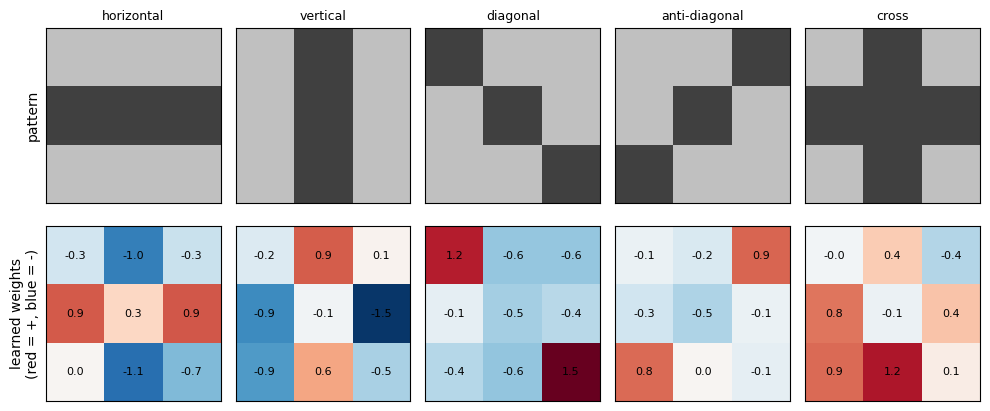

    horizontal bias: -3.15
      vertical bias: -2.71
      diagonal bias: -1.72
 anti-diagonal bias: -0.44
         cross bias: -0.94


In [2]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4.4))
for c, name in enumerate(PAT_NAMES):
    axes[0, c].imshow(-CLEAN[c].reshape(3, 3), cmap="gray", vmin=-2, vmax=2)
    axes[0, c].set_title(name, fontsize=9)
    w = W_pat[c, 1:].reshape(3, 3)
    lim = np.abs(W_pat[:, 1:]).max()
    axes[1, c].imshow(w, cmap="RdBu_r", vmin=-lim, vmax=lim)
    for (i, j), v in np.ndenumerate(w):
        axes[1, c].text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=8)
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].set_ylabel("pattern"); axes[1, 0].set_ylabel("learned weights\n(red = +, blue = -)")
plt.tight_layout(); plt.show()
for c, name in enumerate(PAT_NAMES):
    print(f"{name:>14s} bias: {W_pat[c, 0]:+.2f}")

**B. Counting parameters.** A fully connected layer to 64 hidden units,
against a 1D convolution with 64 filters of width 7 (Day 10), for
inputs of 150 and 1000 residues:

In [3]:
count = lambda layer: sum(p.numel() for p in layer.parameters())
for L in [150, 1000]:
    dense = nn.Linear(L * 20, 64)
    conv = nn.Conv1d(20, 64, kernel_size=7)
    print(f"{L:5d} residues: nn.Linear({L * 20}, 64) has {count(dense):>9,d} parameters;"
          f"  nn.Conv1d(20, 64, 7) has {count(conv):>6,d}")

  150 residues: nn.Linear(3000, 64) has   192,064 parameters;  nn.Conv1d(20, 64, 7) has  9,024
 1000 residues: nn.Linear(20000, 64) has 1,280,064 parameters;  nn.Conv1d(20, 64, 7) has  9,024


**Discuss:**

1. Look at the "horizontal" weights. Which pixels get the most
   *negative* weights? Why would a horizontal-line detector penalize
   exactly those pixels? (Hint: which other pattern shares the middle
   row?) Does the "cross" detector look like a cross?
2. Why does the convolution's parameter count not change at all with
   sequence length? What does it assume about the sequence that the dense
   layer does not?
3. With 486 training proteins, which of these layers would you expect to
   overfit more? (Day 9 and Day 10 measure it.)